In [1]:
import numpy as np
import openml

from data_prep import ColumnSelector
from missing import *
from unlabeled_lr import UnlabeledLogReg

from numpy.typing import ArrayLike

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", ColumnSelector(threshold=0.7)),
    ]
)

def run_experiment(
        X: ArrayLike | pd.DataFrame, 
        y: ArrayLike | pd.Series | pd.DataFrame, 
        mnar_w: float, 
        mar1w: float, 
        mar1b: float, 
        seeds: list[int], 
        approaches: list[str]
        ) -> pd.DataFrame:
    """
    Executes a comprehensive experiment to evaluate different semi-supervised learning 
    approaches for handling missing labels under various missing data mechanisms.

    The function splits the dataset into train, validation, and test sets, applies 
    a preprocessing pipeline, and artificially removes labels based on MCAR, MAR1, 
    MAR2, and MNAR schemes. It then trains an UnlabeledLogReg model using the 
    specified approaches and compares their performance against an Oracle baseline.

    Args:
        X (ArrayLike or pd.DataFrame): The input features dataset.
        y (ArrayLike or pd.Series): The binary target variable.
        mnar_w (float): The weight applied to the true label (Y) in the MNAR scheme.
        mar1w (float): The weight applied to the randomly selected feature in the MAR1 scheme.
        mar1b (float): The bias (intercept) term used in the MAR1 scheme.
        seeds (list[int]): A list of random seeds for reproducible experimental runs.
        approaches (list[str]): A list of string identifiers for the imputation 
            methods to evaluate (e.g., ['naive', 'pseudo_labels']).

    Returns:
        pd.DataFrame: A DataFrame containing the evaluation metrics (Accuracy, 
            Balanced_Acc, F1, ROC_AUC) and the percentage of missing data 
            for each seed, scheme, and approach.
    """
    
    y = np.asarray(y).ravel()
    results = []

    for seed in seeds:
        
        np.random.seed(seed)
        print(f"\n{'='*40}\nExperiment for SEED: {seed}\n{'='*40}")
        
        #Train (60%), Val (20%), Test (20%)

        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.25, random_state=seed, stratify=y_temp
        )
        
        X_train = pipeline.fit_transform(X_train, y_train)
        X_val = pipeline.transform(X_val)
        X_test = pipeline.transform(X_test)
        
        X_train_df = pd.DataFrame(X_train)
        
        y_train_df = pd.DataFrame(y_train, columns=['Y_true_unobserved'])
        y_train_without_missing = y_train_df['Y_true_unobserved'].copy()
        
        y_train_df["Y_observed"] = y_train_df["Y_true_unobserved"].copy().astype(int)
        y_train_df["S"] = 0
        y_train_df["Missing_Y"] = "no"
        
        
        random_col_name = np.random.choice(X_train_df.columns)
        schemes_config = [
        {'name': 'MCAR_0.2', 'type': 'MCAR', 'params': {'p': 0.2}},
        {'name': 'MCAR_0.5', 'type': 'MCAR', 'params': {'p': 0.5}},
        {'name': 'MCAR_0.8', 'type': 'MCAR', 'params': {'p': 0.8}},
        {'name': 'MAR1',     'type': 'MAR1', 'params': {'w': mar1w, 'b': mar1b, 'feature_column': random_col_name}},
        {'name': 'MAR2',     'type': 'MAR2', 'params': {}}, 
        {'name': 'MNAR',     'type': 'MNAR', 'params': {'w_y': mnar_w}}
        ]

        # oracle
        print("  -> Training approach ORACLE...")
        oracle_model = UnlabeledLogReg(y_imputation_method='naive') 
        oracle_model.fit(X_train, y_train_without_missing)
        
        oracle_model.validate(X_val, y_val, measure='balanced_accuracy')
        
        y_pred_oracle = oracle_model.predict(X_test)
        y_prob_oracle = oracle_model.predict_proba(X_test)
        
        results.append({
            'Seed': seed,
            'Scheme': 'None',
            'Approach': 'Oracle',
            'Missing_Percent': 0.0,
            'Accuracy': accuracy_score(y_test, y_pred_oracle),
            'Balanced_Acc': balanced_accuracy_score(y_test, y_pred_oracle),
            'F1': f1_score(y_test, y_pred_oracle),
            'ROC_AUC': roc_auc_score(y_test, y_prob_oracle)
        })

        # iteration over missing mechanisms
        for config in schemes_config:
            scheme_name = config['name']
            scheme_type = config['type']
            print(f"  -> Testing scheme: {scheme_name}")
            
            if scheme_type == 'MCAR':
                y_missing_df = MCAR(y_train_df, **config['params'])
            elif scheme_type == 'MAR1':
                y_missing_df = MAR1(pd.DataFrame(X_train), y_train_df, **config['params'])
            elif scheme_type == 'MAR2':
                y_missing_df = MAR2(pd.DataFrame(X_train), y_train_df, **config['params'])
            elif scheme_type == 'MNAR':
                y_missing_df = MNAR(pd.DataFrame(X_train), y_train_df, **config['params'])
                
            y_train_obs = y_missing_df['Y_observed']
            
            #useful printing % of missing y info  
            missing_count = (y_train_obs == -1).sum()
            total_count = len(y_train_obs)
            missing_pct = round((missing_count / total_count) * 100, 2)
            print(f"     [!] Deleted {missing_pct}% y info ({missing_count}/{total_count})")

            # iteration over approaches
            for approach in approaches:
                print(f"     * Approach: {approach}")
                
                ulr_model = UnlabeledLogReg(y_imputation_method=approach)
                ulr_model.fit(X_train, y_train_obs)
                
                # valdiation
                ulr_model.validate(X_val, y_val, measure='balanced_accuracy')
                
                # calculating performance on outer test data
                y_pred = ulr_model.predict(X_test)
                y_prob = ulr_model.predict_proba(X_test)
                
                results.append({
                    'Seed': seed,
                    'Scheme': scheme_name,
                    'Approach': approach,
                    'Missing_Percent': missing_pct,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Balanced_Acc': balanced_accuracy_score(y_test, y_pred),
                    'F1': f1_score(y_test, y_pred),
                    'ROC_AUC': roc_auc_score(y_test, y_prob)
                })

    results_df = pd.DataFrame(results)
    print("End of experiment")
    
    return results_df

    

In [3]:
def plot_experiment_results(df: pd.DataFrame, metric: str = 'F1') -> None:
    """
    Generates a professional boxplot comparing the performance of different imputation 
    approaches across various missing data mechanisms.

    The function plots the specified evaluation metric for each scheme and approach, 
    and includes a horizontal dashed reference line representing the average score 
    of the Oracle baseline.

    Args:
        df (pd.DataFrame): The DataFrame containing the experimental results, 
            typically the output from the `run_experiment` function.
        metric (str, optional): The name of the evaluation metric to visualize 
            (must match a column in the DataFrame, e.g., 'F1', 'Accuracy', 
            'Balanced_Acc', 'ROC_AUC'). Defaults to 'F1'.

    Returns:
        None: The function displays the matplotlib/seaborn figure.
    """
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    oracle_data = df[df['Approach'] == 'Oracle']
    oracle_mean = oracle_data[metric].mean()
    
    plot_data = df[df['Approach'] != 'Oracle']
    
    ax = sns.boxplot(
        data=plot_data, 
        x='Scheme', 
        y=metric, 
        hue='Approach',
        palette='Set2',
        linewidth=1.5,
        fliersize=5
    )
    
    plt.axhline(
        y=oracle_mean, 
        color='red', 
        linestyle='--', 
        linewidth=2,
        label=f'Oracle Mean ({oracle_mean:.3f})'
    )
    
    plt.title(f'Comparison of approaches - {metric}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Missing Data Mechanism', fontsize=13)
    plt.ylabel(f'{metric} (test data)', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    handles, _ = ax.get_legend_handles_labels()
    plt.legend(
        handles=handles, 
        title='Approach', 
        title_fontsize=12,
        bbox_to_anchor=(1.02, 1), 
        loc='upper left',
        borderaxespad=0.
    )
    
    plt.tight_layout()
    
    plt.show()

In [23]:
def generate_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates experimental results by calculating the mean and standard deviation 
    for key metrics across different missing data mechanisms and imputation approaches.

    Args:
        df (pd.DataFrame): The results DataFrame generated by the `run_experiment` function.

    Returns:
        pd.DataFrame: A formatted summary table with 'Scheme' and 'Approach' as 
        regular columns, and the aggregated metrics represented as 'Mean ± Std'
    """
    expected_metrics = ['Missing_Percent', 'Accuracy', 'Balanced_Acc', 'F1', 'ROC_AUC']
    metrics = [m for m in expected_metrics if m in df.columns]
    
    grouped = df.groupby(['Scheme', 'Approach'])[metrics]
    
    mean_df = grouped.mean()
    std_df = grouped.std().fillna(0) 
    
    summary_df = pd.DataFrame(index=mean_df.index)
    
    for col in metrics:
        if col == 'Missing_Percent':
            summary_df[col] = (
                mean_df[col].map('{:.1f}'.format) + "% ± " + 
                std_df[col].map('{:.1f}'.format) + "%"
            )
        else:
            summary_df[col] = (
                mean_df[col].map('{:.3f}'.format) + " ± " + 
                std_df[col].map('{:.3f}'.format)
            )
            
    return summary_df.reset_index()

In [4]:
#for experiment
seeds = [42, 123, 2026, 67, 5]
approaches = ['naive', 'pseudo_labels', 'iterative_pseudo_labels']

#for visualizations
metrics_to_plot = ['Accuracy', 'Balanced_Acc', 'F1', 'ROC_AUC']

In [5]:
dataset = openml.datasets.get_dataset(5)

arrythmia_X, arrythmia_y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe"
)

arrythmia_y = arrythmia_y.astype(int) 
arrythmia_y_bin = np.where(np.isin(arrythmia_y, [0, 1]), 0, 1) # 0 - healthy

In [6]:
results_arrythmia = run_experiment(arrythmia_X, arrythmia_y_bin, mnar_w=-2, mar1w=4, mar1b=2, seeds=seeds, approaches=approaches)


Experiment for SEED: 42
  -> Training approach ORACLE...
  -> Testing scheme: MCAR_0.2
     [!] Deleted 19.63% y info (53/270)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 16 new confident y values
Discovered 1 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Testing scheme: MCAR_0.5
     [!] Deleted 47.41% y info (128/270)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 43 new confident y values
Discovered 14 new confident y values
Discovered 8 new confident y values
Discovered 2 new confident y values
Discovered 1 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Testing scheme: MCAR_0.8
     [!] Deleted 82.22% y info (222/270)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: it

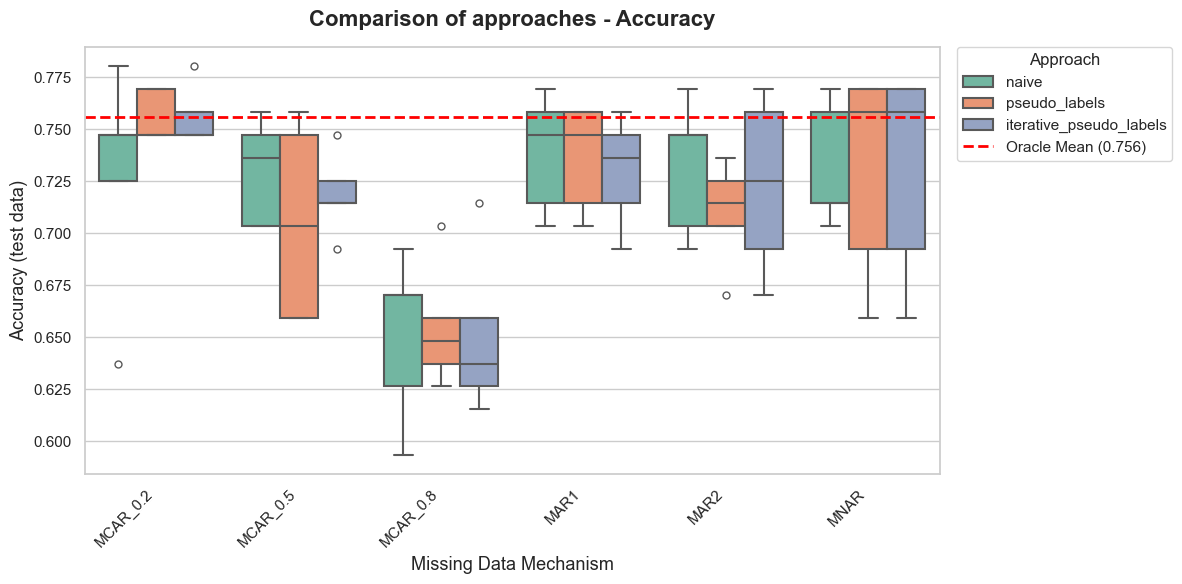

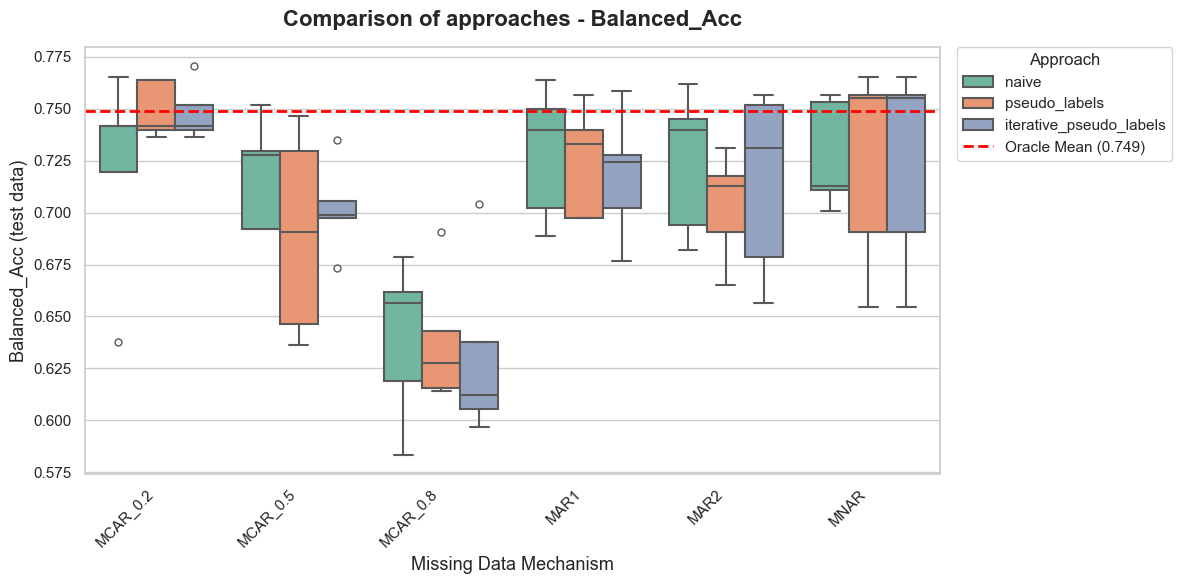

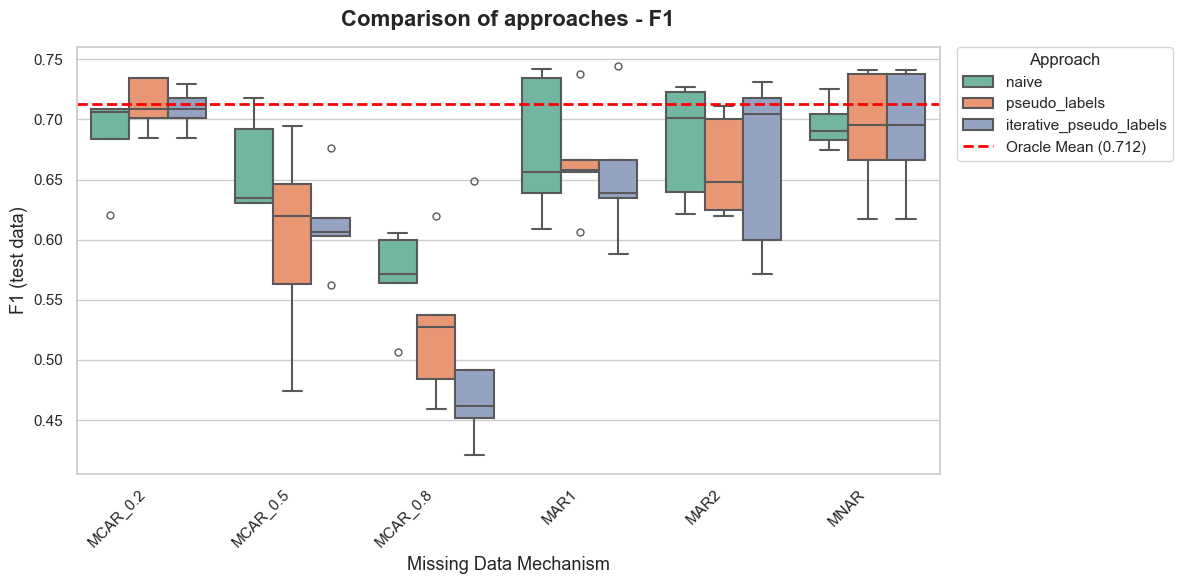

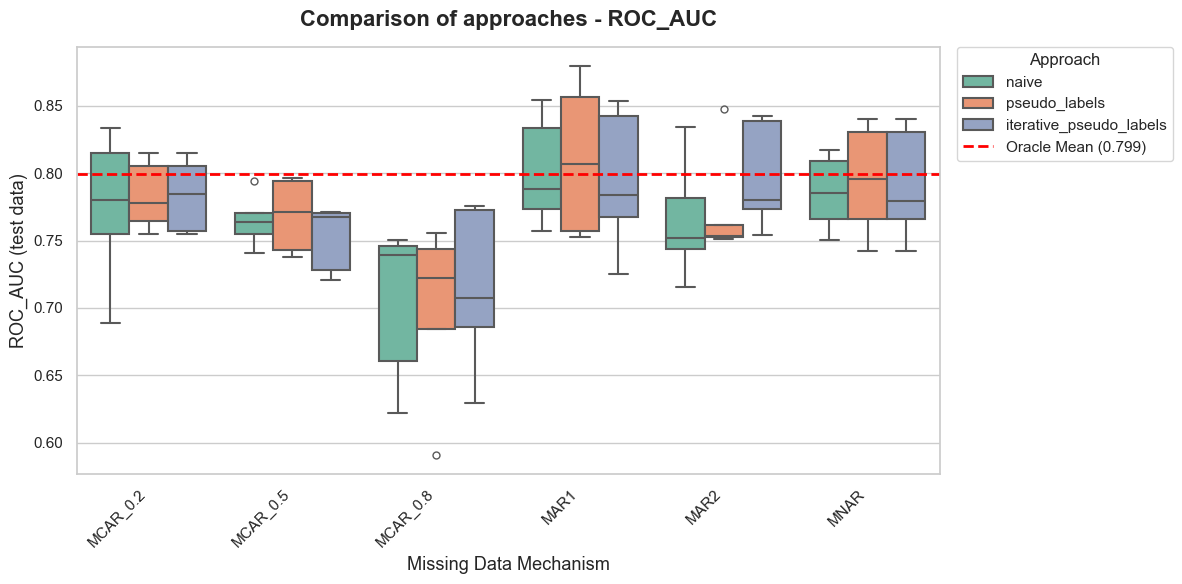

In [7]:
for metric in metrics_to_plot:
    plot_experiment_results(results_arrythmia, metric=metric)

In [24]:
summary_table_arrythmia = generate_summary_table(results_arrythmia)
summary_table_arrythmia

,Scheme,Approach,Missing_Percent,Accuracy,Balanced_Acc,F1,ROC_AUC
0,MAR1,iterative_pseudo_labels,35.6% ± 7.6%,0.730 ± 0.026,0.718 ± 0.030,0.655 ± 0.057,0.795 ± 0.054
1,MAR1,naive,35.6% ± 7.6%,0.738 ± 0.028,0.729 ± 0.032,0.676 ± 0.059,0.801 ± 0.041
2,MAR1,pseudo_labels,35.6% ± 7.6%,0.736 ± 0.026,0.725 ± 0.027,0.665 ± 0.047,0.810 ± 0.057
3,MAR2,iterative_pseudo_labels,24.4% ± 1.9%,0.723 ± 0.042,0.715 ± 0.045,0.665 ± 0.074,0.798 ± 0.040
4,MAR2,naive,24.4% ± 1.9%,0.732 ± 0.033,0.724 ± 0.035,0.683 ± 0.049,0.765 ± 0.045
5,MAR2,pseudo_labels,24.4% ± 1.9%,0.710 ± 0.025,0.703 ± 0.026,0.661 ± 0.042,0.773 ± 0.042
6,MCAR_0.2,iterative_pseudo_labels,20.4% ± 2.6%,0.756 ± 0.014,0.748 ± 0.014,0.709 ± 0.017,0.783 ± 0.028
7,MCAR_0.2,naive,20.4% ± 2.6%,0.727 ± 0.054,0.721 ± 0.049,0.686 ± 0.038,0.775 ± 0.057
8,MCAR_0.2,pseudo_labels,20.4% ± 2.6%,0.756 ± 0.012,0.749 ± 0.013,0.713 ± 0.021,0.784 ± 0.026
9,MCAR_0.5,iterative_pseudo_labels,48.9% ± 3.0%,0.719 ± 0.020,0.702 ± 0.022,0.613 ± 0.041,0.752 ± 0.025


In [8]:
dataset = openml.datasets.get_dataset(1487)

ozone_X, ozone_y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe"
)

ozone_y = ozone_y.astype(int)
ozone_y = np.where(np.isin(ozone_y, [1]), 0, 1)

In [9]:
results_ozone = run_experiment(ozone_X, ozone_y, mnar_w=2, mar1w=1, mar1b=0, seeds=seeds, approaches=approaches)


Experiment for SEED: 42
  -> Training approach ORACLE...
  -> Testing scheme: MCAR_0.2
     [!] Deleted 19.87% y info (302/1520)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 302 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Testing scheme: MCAR_0.5
     [!] Deleted 50.46% y info (767/1520)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 767 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Testing scheme: MCAR_0.8
     [!] Deleted 81.45% y info (1238/1520)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 1238 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Te

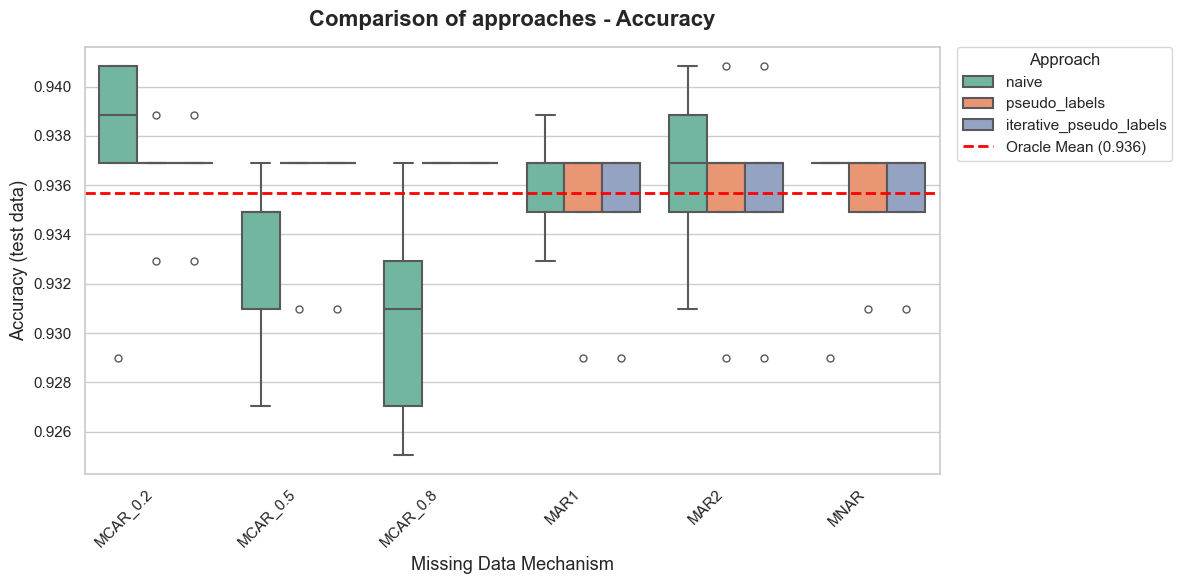

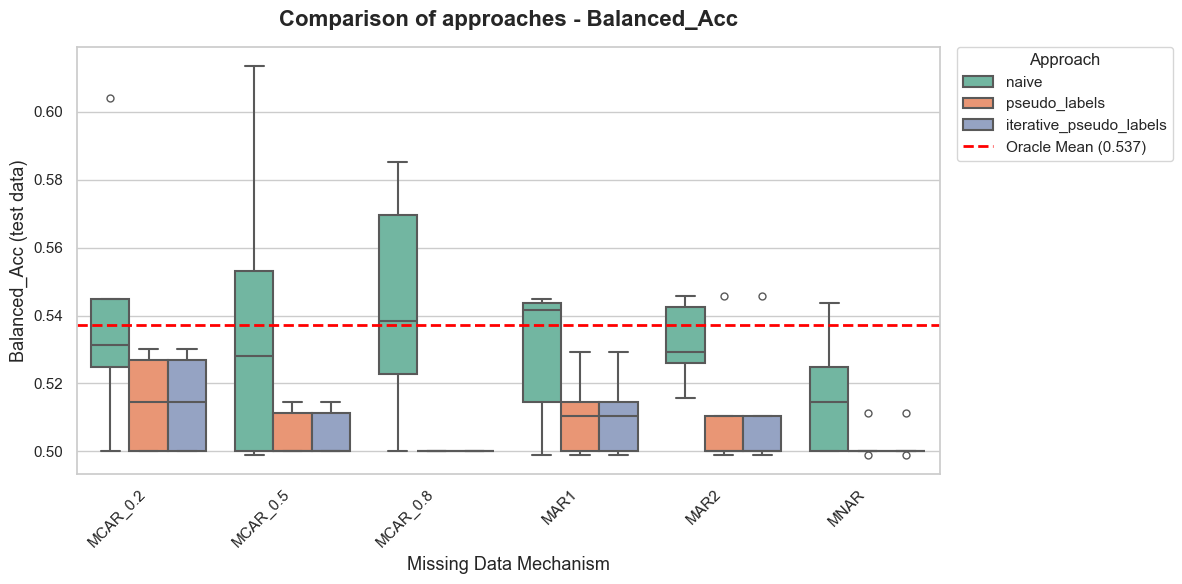

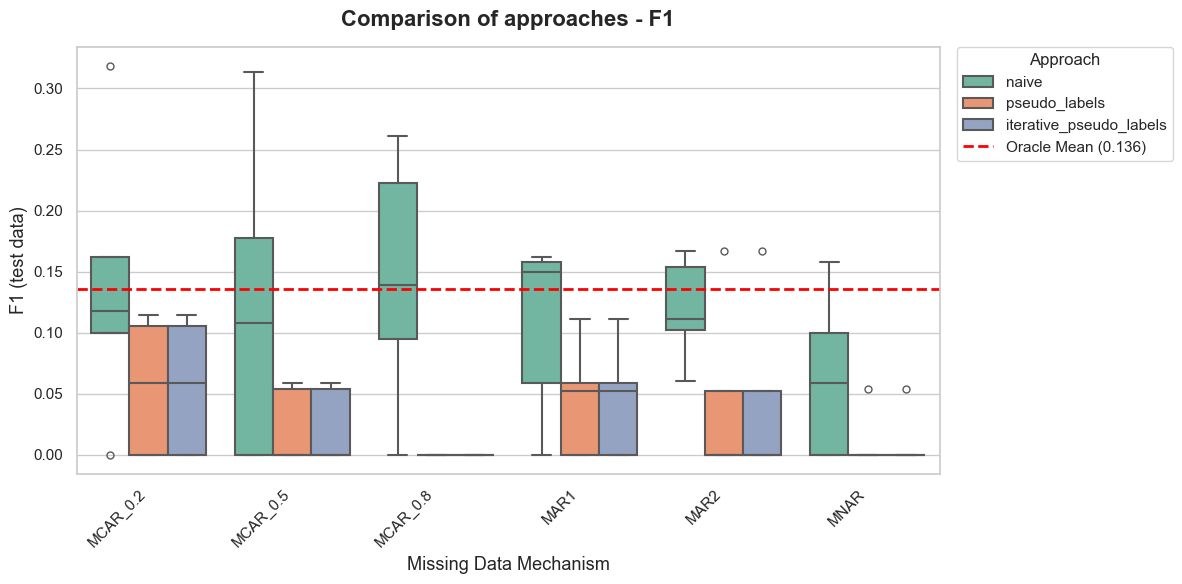

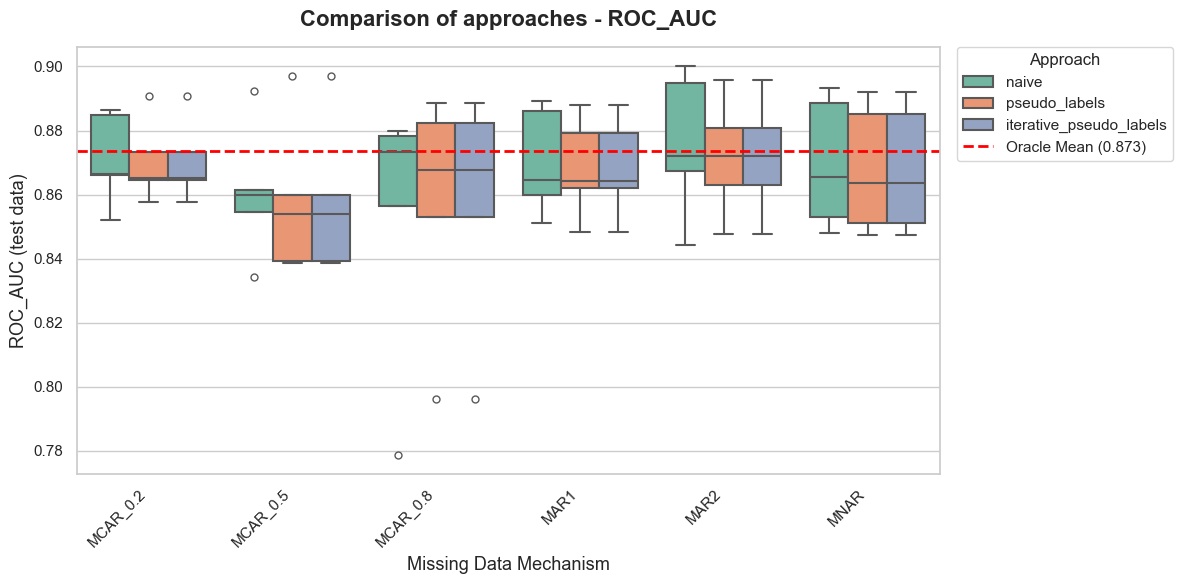

In [10]:
for metric in metrics_to_plot:
    plot_experiment_results(results_ozone, metric=metric)

In [25]:
summary_table_ozone = generate_summary_table(results_ozone)
summary_table_ozone

,Scheme,Approach,Missing_Percent,Accuracy,Balanced_Acc,F1,ROC_AUC
0,MAR1,iterative_pseudo_labels,25.0% ± 1.7%,0.935 ± 0.003,0.511 ± 0.012,0.045 ± 0.047,0.868 ± 0.016
1,MAR1,naive,25.0% ± 1.7%,0.936 ± 0.002,0.529 ± 0.021,0.106 ± 0.073,0.870 ± 0.017
2,MAR1,pseudo_labels,25.0% ± 1.7%,0.935 ± 0.003,0.511 ± 0.012,0.045 ± 0.047,0.868 ± 0.016
3,MAR2,iterative_pseudo_labels,24.9% ± 1.1%,0.936 ± 0.004,0.511 ± 0.020,0.044 ± 0.072,0.872 ± 0.018
4,MAR2,naive,24.9% ± 1.1%,0.936 ± 0.004,0.532 ± 0.012,0.119 ± 0.043,0.876 ± 0.023
5,MAR2,pseudo_labels,24.9% ± 1.1%,0.936 ± 0.004,0.511 ± 0.020,0.044 ± 0.072,0.872 ± 0.018
6,MCAR_0.2,iterative_pseudo_labels,20.6% ± 1.3%,0.936 ± 0.002,0.514 ± 0.014,0.056 ± 0.055,0.870 ± 0.013
7,MCAR_0.2,naive,20.6% ± 1.3%,0.937 ± 0.005,0.541 ± 0.039,0.140 ± 0.116,0.871 ± 0.014
8,MCAR_0.2,pseudo_labels,20.6% ± 1.3%,0.936 ± 0.002,0.514 ± 0.014,0.056 ± 0.055,0.870 ± 0.013
9,MCAR_0.5,iterative_pseudo_labels,50.3% ± 0.9%,0.936 ± 0.003,0.505 ± 0.007,0.023 ± 0.031,0.858 ± 0.024


In [11]:
# pip install ucimlrepo

In [12]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
spam_X = spambase.data.features 
spam_y = spambase.data.targets 

In [13]:
results_spam = run_experiment(spam_X, spam_y, mnar_w=2, mar1w=1, mar1b=0, seeds=seeds, approaches=approaches)


Experiment for SEED: 42
  -> Training approach ORACLE...
  -> Testing scheme: MCAR_0.2
     [!] Deleted 19.71% y info (544/2760)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 239 new confident y values
Discovered 24 new confident y values
Discovered 3 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Testing scheme: MCAR_0.5
     [!] Deleted 49.75% y info (1373/2760)
     * Approach: naive
     * Approach: pseudo_labels
     * Approach: iterative_pseudo_labels
Discovered 614 new confident y values
Discovered 170 new confident y values
Discovered 64 new confident y values
Discovered 16 new confident y values
Discovered 4 new confident y values
Discovered 1 new confident y values
Discovered 1 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...
  -> Testing scheme: MCAR_

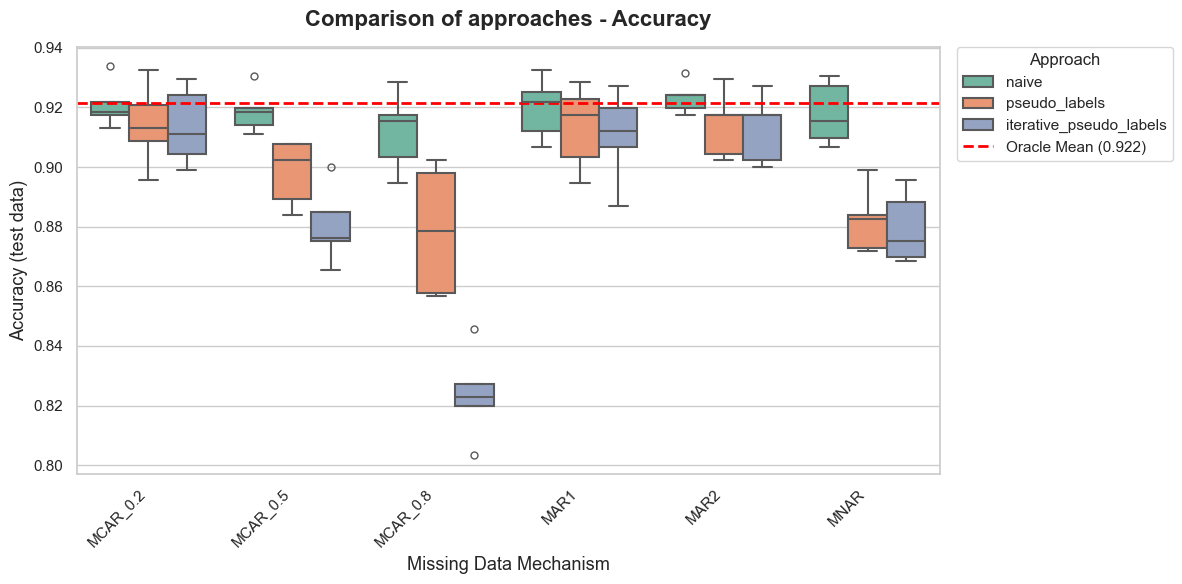

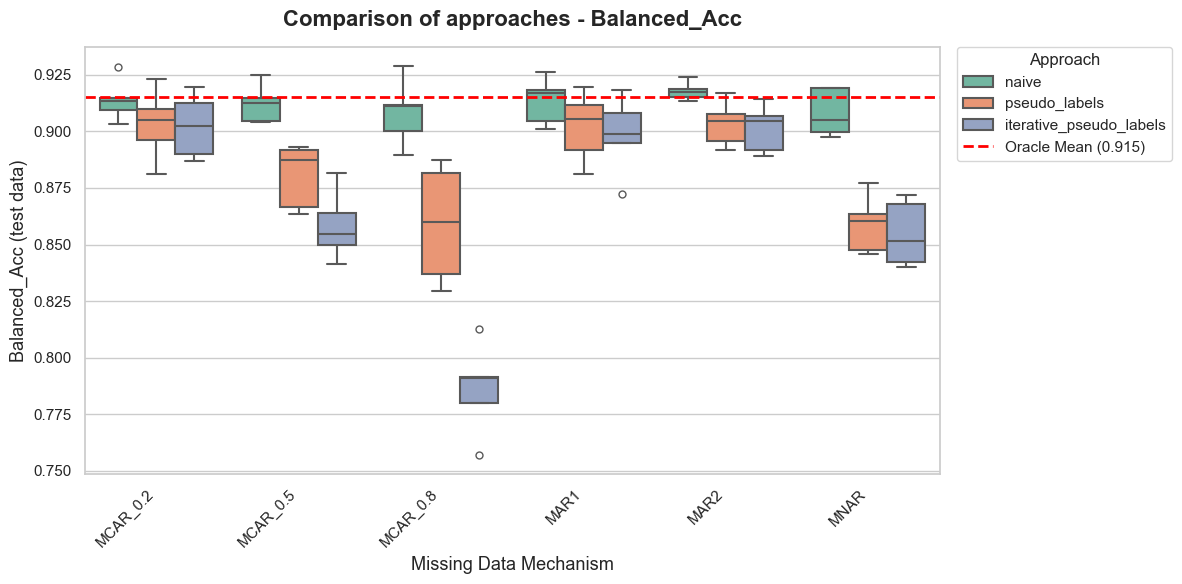

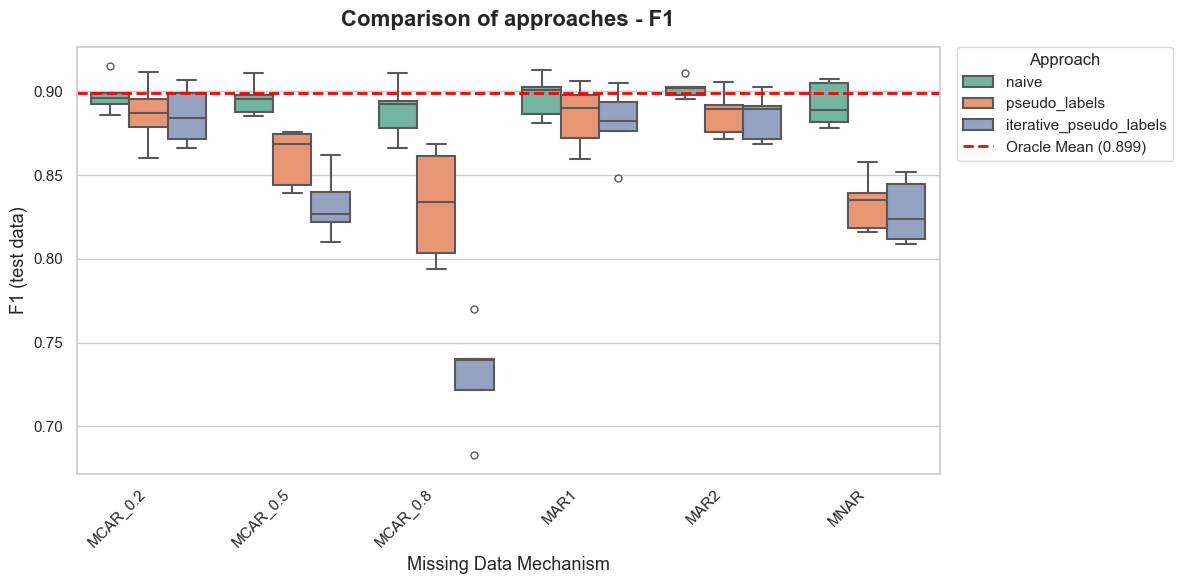

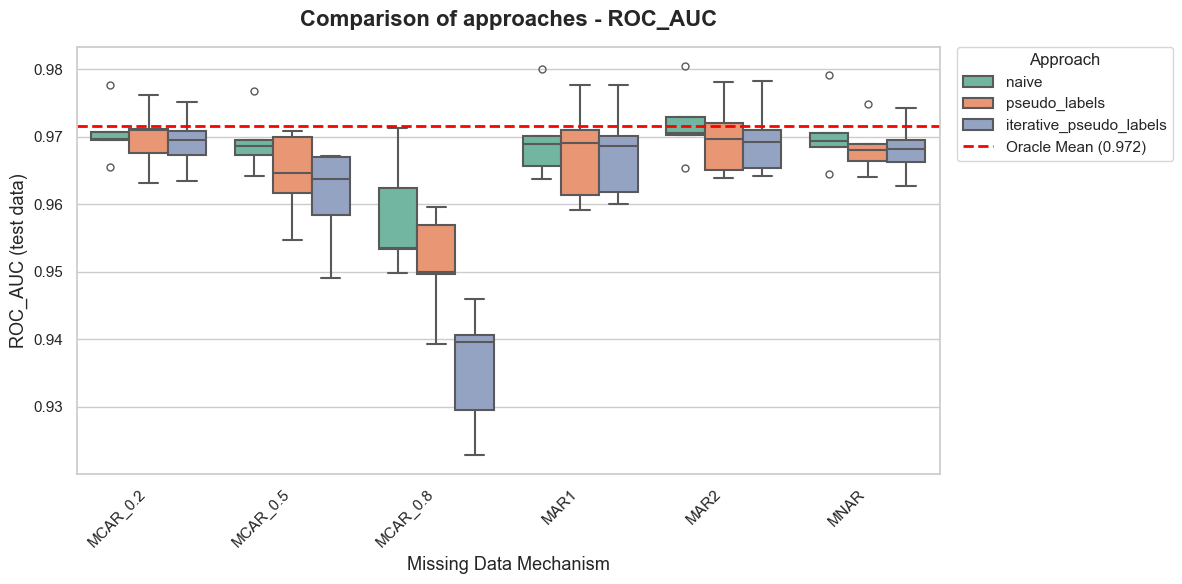

In [14]:
for metric in metrics_to_plot:
    plot_experiment_results(results_spam, metric=metric)

In [26]:
summary_table_spam = generate_summary_table(results_spam)
summary_table_spam

,Scheme,Approach,Missing_Percent,Accuracy,Balanced_Acc,F1,ROC_AUC
0,MAR1,iterative_pseudo_labels,24.7% ± 0.4%,0.911 ± 0.015,0.899 ± 0.017,0.881 ± 0.021,0.968 ± 0.007
1,MAR1,naive,24.7% ± 0.4%,0.920 ± 0.010,0.913 ± 0.010,0.897 ± 0.013,0.970 ± 0.006
2,MAR1,pseudo_labels,24.7% ± 0.4%,0.913 ± 0.014,0.902 ± 0.015,0.885 ± 0.019,0.968 ± 0.007
3,MAR2,iterative_pseudo_labels,24.4% ± 1.0%,0.913 ± 0.011,0.901 ± 0.011,0.885 ± 0.014,0.970 ± 0.006
4,MAR2,naive,24.4% ± 1.0%,0.923 ± 0.005,0.918 ± 0.004,0.902 ± 0.006,0.972 ± 0.005
5,MAR2,pseudo_labels,24.4% ± 1.0%,0.914 ± 0.011,0.903 ± 0.010,0.887 ± 0.014,0.970 ± 0.006
6,MCAR_0.2,iterative_pseudo_labels,20.3% ± 0.9%,0.914 ± 0.013,0.902 ± 0.014,0.886 ± 0.017,0.969 ± 0.004
7,MCAR_0.2,naive,20.3% ± 0.9%,0.921 ± 0.008,0.914 ± 0.009,0.898 ± 0.011,0.971 ± 0.004
8,MCAR_0.2,pseudo_labels,20.3% ± 0.9%,0.914 ± 0.014,0.903 ± 0.016,0.887 ± 0.019,0.970 ± 0.005
9,MCAR_0.5,iterative_pseudo_labels,50.7% ± 0.7%,0.880 ± 0.013,0.858 ± 0.015,0.832 ± 0.020,0.961 ± 0.008
